# Data Preprocessing and Feature Engineering

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import warnings
warnings.filterwarnings('ignore')
from autoreject import AutoReject
from scipy.stats import kurtosis
import os
import requests
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn import svm
import pywt
import pickle
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import entropy

## Data

### Download EDF Files

In [ ]:
# to download edf files, download RECORDS-WITH-SEIZURES file first
# this function was run once to download all the files the first time
def download_files():
    base_url = "https://physionet.org/files/chbmit/1.0.0/"
    output_dir = "data"
    os.makedirs(output_dir, exist_ok=True)
    
    with open("RECORDS-WITH-SEIZURES", "r") as f:
        seizure_files = [line.strip() for line in f if line.strip()]
    
    for file_path in seizure_files:
        url = base_url + file_path
        local_path = os.path.join(output_dir, os.path.basename(file_path))
    
        if os.path.exists(local_path):
            print(f"Already downloaded: {local_path}")
            continue
    
        print(f"Downloading {url} → {local_path}")
        response = requests.get(url)
        if response.status_code == 200:
            with open(local_path, "wb") as f:
                f.write(response.content)
        else:
            print(f"Failed to download {url} (status: {response.status_code})")

### Get Seizure Times

In [ ]:
# function to parse summary files to get seizure times

def parse_seizure_text(text):
    seizure_windows = defaultdict(dict)
    current_file = None
    current_seizures = []
    
    lines = text.strip().splitlines()
    for line in lines:
        line = line.strip()
        
        # new edf file we are looking at
        if line.startswith("File Name:"):
            # save previous file + seizures if we have them
            if current_file and current_seizures:
                patient_id = current_file[3:5]
                file_id = current_file[6:8]
                seizure_windows[patient_id][file_id] = current_seizures
            # get new file name
            current_file = line.split(":")[1].strip()
            # reset seizures
            current_seizures = []

        # seizure starts
        elif line.startswith("Seizure") and ("Start Time" in line) :
            start = int(line.split(":")[1].strip().split()[0])
            current_seizures.append([start, None])

        # seizure ends
        elif line.startswith("Seizure") and ("End Time" in line) :
            end = int(line.split(":")[1].strip().split()[0])
            if current_seizures:
                current_seizures[-1][1] = end
    
    # add last file if exists
    if current_file and current_seizures:
        patient_id = current_file[3:5]
        file_id = current_file[6:8]
        seizure_windows[patient_id][file_id] = current_seizures

    return seizure_windows

In [ ]:
seizures_windows = defaultdict(dict)
patients = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', 
           '15', '16', '17', '18', '19', '20', '21', '22', '23', '24']

for p in patients:
    path = 'data/summaries/chb' + p + '-summary.txt'
    with open(path, "r") as f:
        text = f.read()
    seizures_windows = seizures_windows | parse_seizure_text(text)

seizures_windows

In [ ]:
# saving seizures windows so they don't have to be reparsed every time
with open('seizures_windows.pkl', 'wb') as f:
    pickle.dump(seizures_windows, f)

## Data Preprocessing

The following functions filter the raw EEG data, epoch it using the previously obtained seizure times, and finally remove artifacts using ICA.

In [ ]:
# function to filter raw EEG data

def preprocess_edf(file_path, notch_freqs = [60], high_pass = 0.1, low_pass = 70):
    # load in raw edf file
    raw = mne.io.read_raw_edf(file_path, verbose=False)
    raw.load_data()

    # dataset uses bipolar montage (e.g. FP1-F7), so setting dummy positions for montage for artifact removal later
    n_channels = len(raw.ch_names)
    pos = np.random.randn(n_channels, 3)  # random 3D positions
    montage = mne.channels.make_dig_montage(ch_pos = {name: p for name, p in zip(raw.ch_names, pos)})
    raw.set_montage(montage)
    
    # high-pass filter to reduce drifts in signal caused by head movements and perspiration
    raw.filter(l_freq = high_pass, h_freq = None, verbose = False)

    # low-pass filter to reduce muscular artifacts and other high-frequency noise
    raw.filter(l_freq = None, h_freq = low_pass, verbose = False)
    
    # notch filter to remove power line noise (60Hz)
    raw.notch_filter(freqs=notch_freqs, verbose=False)

    return raw

In [ ]:
# function to epoch raw data into epochs around seizures
# pass seizure times using seizure_windows dictionary + filename, not overlapping windows

def epoch_data(raw, seizure_times, epoch_length = 5, preictal = 10, sampling_rate = 256):
    # look at data up to one hour before each seizure, cut if that conflicts with a seizure
    windows = []
    last_seizure_end = 0
    for seizure in seizure_times:
        start = max(last_seizure_end, seizure[0] - preictal * 120)
        start = start + ((seizure[0] - start) % 5) # ensure 5 second windows fits exactly  
        windows.append((start, seizure[0]))
        last_seizure_end = seizure[1]

    events = []
    for start, end in windows:
        for i in range(start, end + 1, epoch_length):
            label = 1 if (i + epoch_length >= end - preictal * 60) else 0
            events.append([i * sampling_rate, 0, label])

    events = np.array(events, dtype = int)
    
    event_id = dict(normal=0, preictal=1)
    labels_present = set(e[2] for e in events)
    event_id = {k: v for k, v in event_id.items() if v in labels_present}
    
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0,
        tmax=epoch_length,
        baseline=None,
        preload=True,
    )
    
    return epochs

In [ ]:
# function to remove EEG artifacts from epoched data

def fit_ica(epochs):
    # ica filtering
    ica_low = 1.0
    ica_high = 70
    epochs_ica = epochs.copy().filter(ica_low, ica_high, verbose = False)

    # autoreject determining threshold for noise
    ar = AutoReject(n_interpolate = [1, 2, 4], random_state = 42,
                    picks = mne.pick_types(epochs_ica.info, eeg = True, eog = False), verbose = False)
    ar.fit(epochs_ica)
    reject_log = ar.get_reject_log(epochs_ica)
    good_epochs = epochs_ica[~reject_log.bad_epochs]

    # fitting ica to the data
    ica = mne.preprocessing.ICA(n_components = 0.99, random_state = 42) # 0.99 means components explain 99% of variance in data
    ica.fit(good_epochs, decim = 3)

    # finding noisy components using kurtosis
    sources = ica.get_sources(good_epochs).get_data()
    comp_kurt = kurtosis(sources, axis=1)
    threshold = np.percentile(comp_kurt, 95)
    bad_components = np.where(comp_kurt >= threshold)[0]
    
    ica.exclude = list(bad_components)
    
    return ica, good_epochs

### Filtering

In [ ]:
cleaned_data = defaultdict(dict)

In [ ]:
file_path = 'raw'
all_file_names = os.listdir(file_path)
all_file_names = [f for f in all_file_names if '.edf' in f]
all_file_names.sort()
for filename in all_file_names:
    full_fn = file_path + '/' + filename
    print("----------Cleaning " + filename + "----------")
    patient_id = filename[3:5]
    file_id = filename[6:8]
    curr_file_filt = preprocess_edf(full_fn)
    cleaned_data[patient_id][file_id] = curr_file_filt

### Epoching

In [ ]:
epoched_data = defaultdict(dict)

In [ ]:
for patient_id in cleaned_data:
    for file_id in cleaned_data[patient_id]:
        print("----------Epoching " + patient_id  + ":" + file_id + "----------")
        epochs = epoch_data(cleaned_data[patient_id][file_id], seizures_windows[patient_id][file_id])
        epoched_data[patient_id][file_id] = epochs

### Artifact Removal

In [ ]:
data = defaultdict(dict)

In [ ]:
for patient_id in epoched_data:
    for file_id in epoched_data[patient_id]:
        print("----------Preprocessing " + patient_id + ":" + file_id + "----------")
        epochs = epoched_data[patient_id][file_id]
        curr_ica, curr_epochs = fit_ica(epochs)
        data[patient_id][file_id] = curr_epochs
        curr_ica.info.set_meas_date(None)
        curr_ica.save('data/icas/' + patient_id + "_" + file_id + '_ica.fif', overwrite = True)

### Saving Epoched Data

In [ ]:
for patient_id in data:
    for file_id in data[patient_id]:
        data[patient_id][file_id].info.set_meas_date(None)
        data[patient_id][file_id].save('data/epochs/' + patient_id + "_" + file_id + '_epo.fif', overwrite = True)

### Visualizing Average Frequency Band Power

In [5]:
epochs_0103 = epochs_list['01']['04']
normal_epochs = epochs_0103['normal']
preictal_epochs = epochs_0103['preictal']

In [6]:
psd_normal = normal_epochs.compute_psd(fmin = 1, fmax = 50)
psd_preictal = preictal_epochs.compute_psd(fmin = 1, fmax = 50)

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


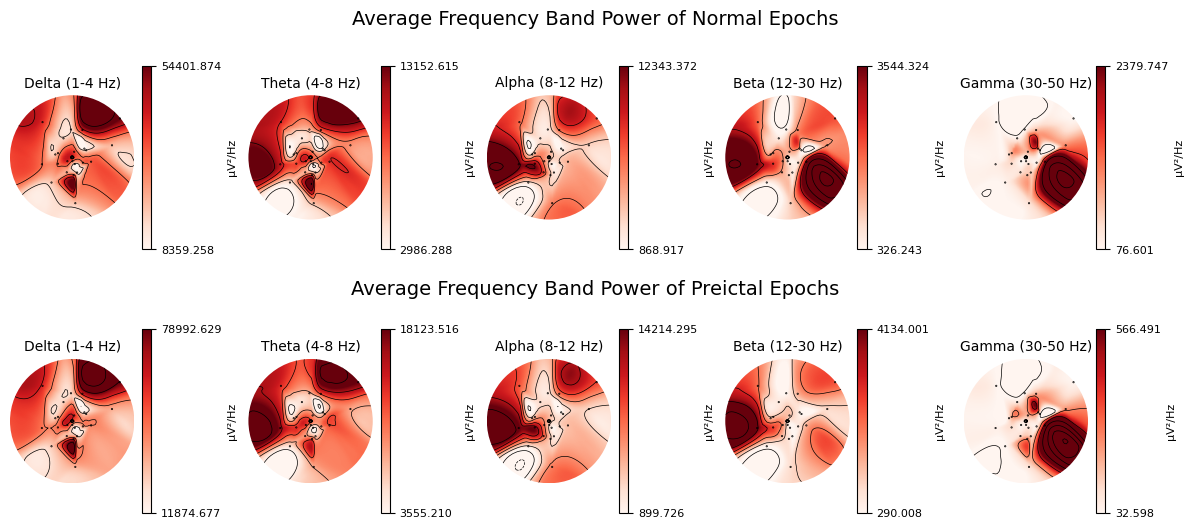

In [7]:
freq_bands = {
    'Delta (1-4 Hz)': (1, 4),
    'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-12 Hz)': (8, 12),
    'Beta (12-30 Hz)': (12, 30),
    'Gamma (30-50 Hz)': (30, 50)
}

fig, axs = plt.subplots(2, 5, figsize=(12, 6))

# normal epochs
psd_normal.plot_topomap(bands = freq_bands, axes = axs[0], show = False)
fig.text(0.5, 0.95, 'Average Frequency Band Power of Normal Epochs', ha='center', va='center', fontsize=14)

# preictal epochs
psd_preictal.plot_topomap(bands = freq_bands, axes = axs[1], show = False)
fig.text(0.5, 0.5, 'Average Frequency Band Power of Preictal Epochs', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

## Feature Extraction

### Loading in All Epoch Files

In order to not run all of the pre-processing steps every time, we can simply load in the already saved epoched data from the previous step. We also can load in the seizures windows from the pickle file that was created before.

In [2]:
epochs_list = defaultdict(dict)

In [3]:
for fname in sorted(os.listdir('data/epochs/')):
    if fname.endswith('_epo.fif'):
        patient_id = fname[0:2]
        file_id = fname[3:5]
        ep = mne.read_epochs(os.path.join('data/epochs/', fname), preload = True, verbose = False)
        epochs_list[patient_id][file_id] = ep

In [4]:
with open('seizures_windows.pkl', 'rb') as f:
    seizures_windows = pickle.load(f)

### Standardizing Channels

Since "dummy" signals were inserted into channel names for some cases, not every patient has all of the channel names. First, we need to standardize the `T8-P8` channel names since there are multiple ones in the dataset. Then, the inconsistent channels need to be identified and ommitted from the data set since it will result in NaN values during feature engineering.

In [8]:
# mapping to standardize channel names
channel_rename_map = {
    'T8-P8-0': 'T8-P8',
}

for patient_id in epochs_list:
    for file_id in epochs_list[patient_id]:
        epochs = epochs_list[patient_id][file_id]
        ch_names = epochs.info['ch_names']
        
        # renaming channel if needed
        rename_dict = {ch: channel_rename_map.get(ch, ch) for ch in ch_names}
        
        # saving renamed channels back to the epochs object
        epochs.rename_channels(rename_dict)

In [9]:
# dropping files that have inconsistent channels/references
# these were found manually through summary files
del epochs_list['12']['27']
del epochs_list['12']['28']
del epochs_list['12']['29']

In [10]:
file_channels = {}

for patient_id in epochs_list:
    for file_id in epochs_list[patient_id]:
        epochs = epochs_list[patient_id][file_id]
        ch_names = epochs.info['ch_names']
        file_channels[(patient_id, file_id)] = set(ch_names)

# getting intersection of channels
shared_channels = set.intersection(*file_channels.values())
all_channels = set.union(*file_channels.values())

# channels not in all patients
inconsistent_channels = all_channels - shared_channels

print("Inconsistent channels (not in every patient):")
print(inconsistent_channels)

Inconsistent channels (not in every patient):
{'LOC-ROC', 'FT9-FT10', 'CP6-Ref', '.-0', 'CP2-Ref', '.-4', 'FC5-Ref', 'FC1-Ref', 'FC6-Ref', '.-2', '--2', 'CP1-Ref', 'P7-T7', 'T8-P8-1', 'VNS', 'FC2-Ref', 'PZ-OZ', '--5', 'ECG', '--4', '.-3', 'FT10-T8', 'CP5-Ref', 'T7-FT9', '--0', '--1', '.-1', '--3'}


In [11]:
# dropping inconsistent channels
for patient_id in epochs_list:
    for file_id in epochs_list[patient_id]:
        epochs = epochs_list[patient_id][file_id]
        ch_names = epochs.info['ch_names']
        
        # filtering out inconsistent channels
        channels_to_drop = [ch for ch in ch_names if ch in inconsistent_channels]
        
        # dropping those channels from the epochs object
        if channels_to_drop:
            epochs.drop_channels(channels_to_drop)

### Time-Domain Features

In [12]:
time_rows = []
for patient_id in epochs_list:
    for file_id in epochs_list[patient_id]:
        epochs = epochs_list[patient_id][file_id]
        data = epochs.get_data(units = 'uV')

        ch_names = epochs.info['ch_names']

        for epoch_idx, epoch in enumerate(data):
            epoch_features = {}
            for ch_idx, ch_data in enumerate(epoch):
                ch_name = ch_names[ch_idx]
                # baseline activity
                epoch_features[f'{ch_name}_mean'] = np.mean(ch_data)
                # signal variability
                epoch_features[f'{ch_name}_std'] = np.std(ch_data)
                # asymmetry and sharp peaks
                epoch_features[f'{ch_name}_kurtosis'] = kurtosis(ch_data)

            row = {
                'patient_id': patient_id,
                'file_id': file_id,
                'epoch_index': epoch_idx,
                **epoch_features
            }
            time_rows.append(row)
time_features_df = pd.DataFrame(time_rows)

In [13]:
time_features_df.sample(5)

,patient_id,file_id,epoch_index,FP1-F7_mean,FP1-F7_std,FP1-F7_kurtosis,F7-T7_mean,F7-T7_std,F7-T7_kurtosis,T7-P7_mean,...,T8-P8_kurtosis,P8-O2_mean,P8-O2_std,P8-O2_kurtosis,FZ-CZ_mean,FZ-CZ_std,FZ-CZ_kurtosis,CZ-PZ_mean,CZ-PZ_std,CZ-PZ_kurtosis
28907,24,11,203,-0.621362,17.512858,2.097065,-0.401257,23.800791,1.074909,0.664708,...,-0.057863,-0.207393,21.450131,-0.099843,0.667335,22.258175,0.410622,-0.810796,18.212904,-0.112872
17207,15,10,59,0.049420,6.799254,0.311156,-0.278281,8.706824,0.859421,-0.326523,...,-0.283915,-0.498162,12.139893,0.033547,-0.550960,9.841281,0.290254,0.015603,9.908790,-0.266673
6447,08,05,42,1.544819,99.812250,2.011494,1.920037,108.858216,8.925774,-0.473729,...,1.698346,0.410990,96.153790,0.724704,-0.016470,55.623346,15.358965,1.181203,35.516123,4.499524
5184,06,09,181,-0.053272,33.980535,2.519163,-1.139430,44.601569,1.720070,-0.813147,...,0.429738,-2.176163,41.166019,0.394324,-4.303593,47.183186,0.964175,-1.313061,48.699293,1.241942
3455,05,16,122,-0.865341,52.569312,5.162478,-2.438415,73.612209,0.729752,-0.821800,...,4.494845,-1.776511,44.126791,5.000615,-3.382216,61.515701,1.307335,-1.139549,41.620462,2.810660


### Frequency-Domain Features

In [14]:
freq_rows = []

# frequency bands
freq_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'gamma': (30, 50)
}

for patient_id in epochs_list:
    for file_id in epochs_list[patient_id]:
        epochs = epochs_list[patient_id][file_id]
        ch_names = epochs.info['ch_names']
        psds = epochs.compute_psd(method = 'welch', fmin = 1, fmax = 50, verbose = False)
        freqs = psds.freqs
        psd_data = psds.get_data()
        # compute_psd() returns volts, so converting powers to microvolts
        psd_data = psd_data * 1e12

        for epoch_idx, epoch_psd in enumerate(psd_data):
            epoch_features = {}
            for ch_idx, ch_psd in enumerate(epoch_psd):
                ch_name = ch_names[ch_idx]

                # getting average power per frequency band in channel
                for band_name, (fmin, fmax) in freq_bands.items():
                    band_mask = (freqs >= fmin) & (freqs < fmax)
                    band_power = np.mean(ch_psd[band_mask])
                    epoch_features[f'{ch_name}_{band_name}_power'] = band_power
            row = {
                'patient_id': patient_id,
                'file_id': file_id,
                'epoch_index': epoch_idx,
                **epoch_features
            }
            freq_rows.append(row)
frequency_features_df = pd.DataFrame(freq_rows)

In [15]:
frequency_features_df.sample(5)

,patient_id,file_id,epoch_index,FP1-F7_delta_power,FP1-F7_theta_power,FP1-F7_alpha_power,FP1-F7_beta_power,FP1-F7_gamma_power,F7-T7_delta_power,F7-T7_theta_power,...,FZ-CZ_delta_power,FZ-CZ_theta_power,FZ-CZ_alpha_power,FZ-CZ_beta_power,FZ-CZ_gamma_power,CZ-PZ_delta_power,CZ-PZ_theta_power,CZ-PZ_alpha_power,CZ-PZ_beta_power,CZ-PZ_gamma_power
14460,13,58,202,94.826077,28.117034,1.825902,0.722595,0.629881,140.768218,37.359371,...,70.007088,18.164367,12.522816,0.953215,0.255145,91.393751,56.035198,10.945150,1.070831,0.279732
1599,03,02,52,38.682469,7.903959,5.885915,0.515077,0.038805,48.398801,8.762918,...,29.215917,13.795082,10.390138,1.267536,0.053065,25.341512,12.179226,4.840467,0.742456,0.053843
16415,14,11,216,327.396147,36.693703,36.533479,4.501844,0.567822,650.657170,32.093368,...,2049.481230,124.177386,83.311761,11.415533,0.871818,1273.790538,67.618349,57.460030,8.138955,1.049198
12348,12,33,275,34.557268,9.838341,2.447887,2.292396,0.617186,65.988190,17.396473,...,86.779088,46.156637,26.126161,10.423587,1.062082,154.058397,33.486958,9.828733,7.008550,0.776698
9388,10,31,145,1380.888413,126.077802,14.517853,2.077139,0.989355,2299.894412,293.897914,...,3277.184379,779.222594,48.147064,3.371558,0.314908,1613.026257,760.655826,34.107113,2.562603,0.181742


### Wavelet Transformation Features

In [16]:
dwt_rows = []

def compute_wavelet_features(signal, wavelet = 'db4', level = 4):
    # decompose into sub-bands
    coefs = pywt.wavedec(signal, wavelet = wavelet, level = level)
    
    energies = np.array([np.sum(np.square(c)) for c in coefs])
    total_energy = np.sum(energies)

    features = {}
    for i, c in enumerate(coefs):
        if i != 0:
            band = f'dwt_D{level}'
        else:
            band = f'dwt_A{level}'
        features[f'{band}_std'] = np.std(c)
        features[f'{band}_kurtosis'] = kurtosis(c)
        features[f'{band}_energy'] = np.sum(np.square(c))
        features[f'{band}_rel_energy'] = features[f'{band}_energy'] / total_energy if total_energy else 0
        
        # sub-band wavelet entropy for each band
        prob_c = np.abs(c) / np.sum(np.abs(c)) if np.sum(np.abs(c)) else np.ones_like(c) / len(c)
        swe = entropy(prob_c, base = 2)
        features[f'{band}_wavelet_entropy'] = swe
        
        # sub-band logarithmic band power
        band_power = np.mean(np.square(c))
        log_power = np.log10(band_power + 1e-10)
        features[f'{band}_lbp'] = log_power
        
    return features

for patient_id in epochs_list:
    for file_id in epochs_list[patient_id]:
        epochs = epochs_list[patient_id][file_id]
        ch_names = epochs.info['ch_names']
        data = epochs.get_data()

        for epoch_idx, epoch_data in enumerate(data):
            epoch_features = {}
            for ch_idx, ch_signal in enumerate(epoch_data):
                ch_name = ch_names[ch_idx]
                dwt_feats = compute_wavelet_features(ch_signal)

                for feat_name, val in dwt_feats.items():
                    epoch_features[f'{ch_name}_{feat_name}'] = val
            
            row = {
                'patient_id': patient_id,
                'file_id': file_id,
                'epoch_index': epoch_idx,
                **epoch_features
            }
            dwt_rows.append(row)

dwt_features_df = pd.DataFrame(dwt_rows)

In [17]:
dwt_features_df.sample(5)

,patient_id,file_id,epoch_index,FP1-F7_dwt_A4_std,FP1-F7_dwt_A4_kurtosis,FP1-F7_dwt_A4_energy,FP1-F7_dwt_A4_rel_energy,FP1-F7_dwt_A4_wavelet_entropy,FP1-F7_dwt_A4_lbp,FP1-F7_dwt_D4_std,...,CZ-PZ_dwt_A4_energy,CZ-PZ_dwt_A4_rel_energy,CZ-PZ_dwt_A4_wavelet_entropy,CZ-PZ_dwt_A4_lbp,CZ-PZ_dwt_D4_std,CZ-PZ_dwt_D4_kurtosis,CZ-PZ_dwt_D4_energy,CZ-PZ_dwt_D4_rel_energy,CZ-PZ_dwt_D4_wavelet_entropy,CZ-PZ_dwt_D4_lbp
561,01,15,140,0.000228,0.840365,4.489364e-06,0.914659,5.835485,-7.281482,8.381624e-07,...,7.333016e-06,0.917482,5.819374,-7.068707,7.806065e-07,-0.209766,3.924198e-10,0.000049,8.940228,-9.997362
13017,12,42,16,0.000053,-0.555623,2.411917e-07,0.757182,6.033567,-8.536920,7.462794e-07,...,1.085137e-06,0.838224,6.082678,-7.895586,1.031204e-06,0.055791,6.848182e-10,0.000529,8.925313,-9.995406
22921,19,29,115,0.000055,1.021946,2.608953e-07,0.835081,5.898568,-8.503947,1.207613e-06,...,2.599248e-07,0.736278,6.018863,-8.505514,7.459830e-07,0.409533,3.583800e-10,0.001015,8.901303,-9.997590
17304,15,10,156,0.000023,1.757759,4.394501e-08,0.651023,5.761751,-9.213967,5.693967e-07,...,1.027242e-07,0.609496,5.933969,-8.887909,7.282722e-07,0.114842,3.415666e-10,0.002027,8.902405,-9.997703
721,01,16,66,0.000094,1.051719,7.576162e-07,0.761156,5.934951,-8.050147,7.949790e-07,...,9.340630e-07,0.728665,5.870600,-7.960142,1.306967e-06,-0.597953,1.100057e-09,0.000858,8.961487,-9.992644


#### Visualizing DWT and Signal Decomposition

In [18]:
subject_data = epochs_list['01']['03'].get_data()
epoch0_data = subject_data[0]
signal = epoch0_data[0]
coefs = pywt.wavedec(signal, wavelet = 'db4', level = 4)

In [19]:
det_levels = len(coefs) - 1 
frequency_ranges = {}
sampling_freq = 256

# calculating frequency ranges for each sub-band
for i in range(1, det_levels + 1):
    low_freq = sampling_freq / (2 ** (i+1))
    high_freq = sampling_freq / (2 ** (i))
    frequency_ranges[f"Detail D{i}"] = (low_freq, high_freq)

approx_freq = (0, sampling_freq / (2 ** (det_levels + 1)))
frequency_ranges["Approximation cA"] = approx_freq
frequency_ranges

{'Detail D1': (64.0, 128.0),
 'Detail D2': (32.0, 64.0),
 'Detail D3': (16.0, 32.0),
 'Detail D4': (8.0, 16.0),
 'Approximation cA': (0, 8.0)}

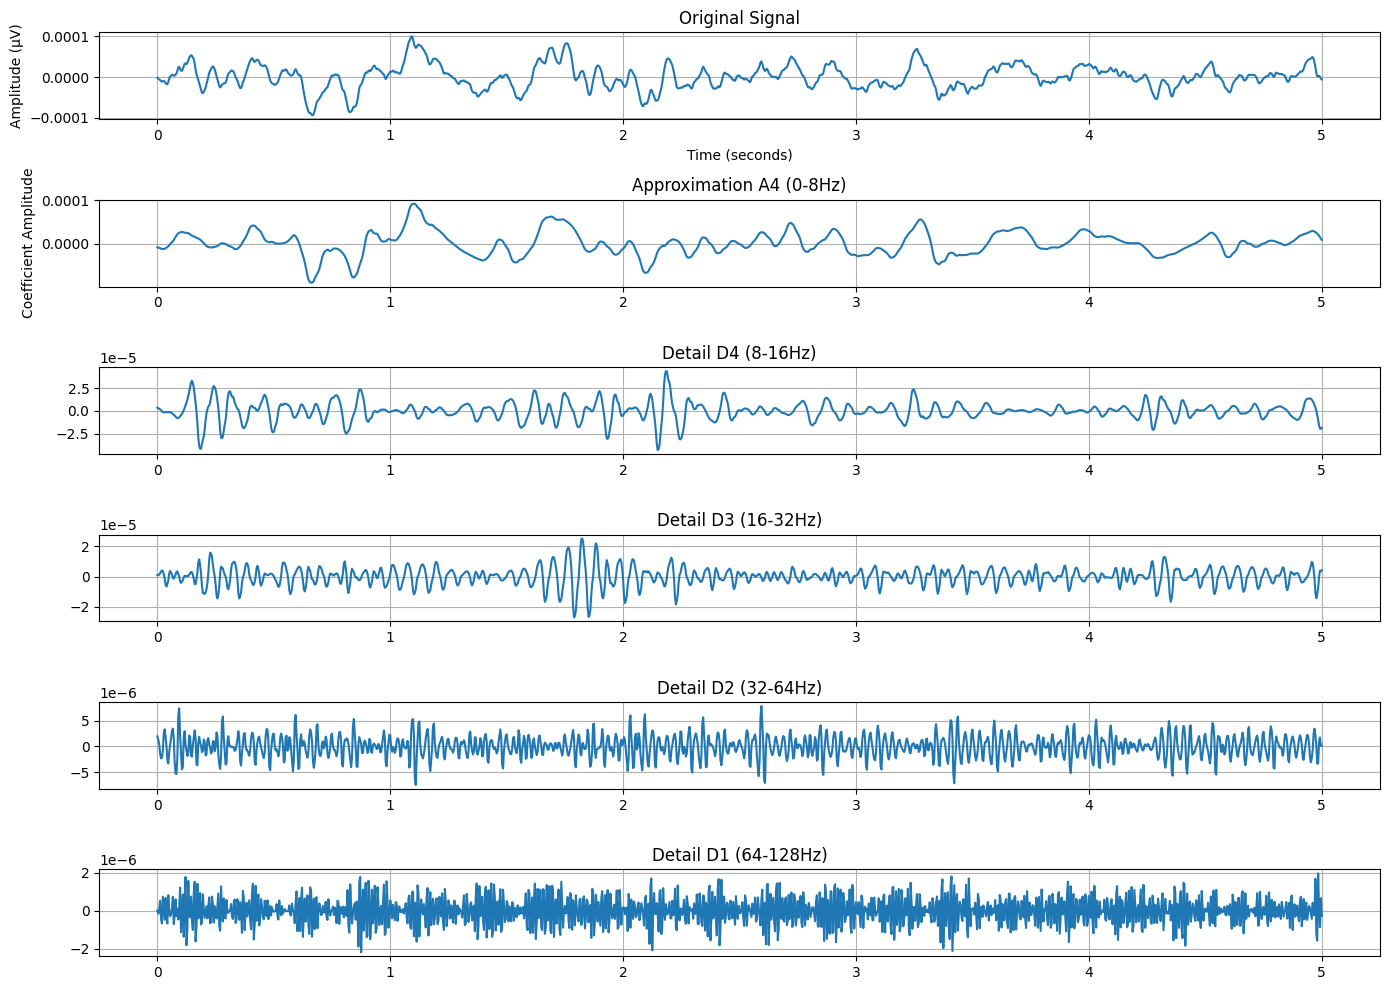

In [20]:
components = []
wavelet = 'db4'
level = 4
t = t = np.linspace(0, 5, len(signal))

# approximation
cA_only = [coefs[0]] + [np.zeros_like(c) for c in coefs[1:]]
A_rec = pywt.waverec(cA_only, wavelet)
A_rec = A_rec[:len(signal)]
components.append(('Approximation A4 (0-8Hz)', A_rec))

# details
for i in range(1, level + 1):
    detail_only = [np.zeros_like(c) if j != i else coefs[j] for j, c in enumerate(coefs)]
    D_rec = pywt.waverec(detail_only, wavelet)
    D_rec = D_rec[:len(signal)]
    component_name = f"Detail D{det_levels - i + 1}"
    component_freq_range = frequency_ranges[component_name]
    formatted_freq_range = f"({int(component_freq_range[0])}-{int(component_freq_range[1])}Hz)"
    components.append((f"{component_name} {formatted_freq_range}", D_rec))

# plotting
plt.figure(figsize=(14, 10))
plt.subplot(len(components) + 1, 1, 1)
plt.plot(t, signal, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (µV)')
plt.grid(True)

for i, (label, comp) in enumerate(components, start=2):
    plt.subplot(len(components) + 1, 1, i)
    plt.plot(t, comp, label=label)
    plt.title(label)
    if i == 2: plt.ylabel('Coefficient Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Adding Epoch Labels

In [21]:
label_rows = []

for patient_id in epochs_list:
    for file_id in epochs_list[patient_id]:
        epochs = epochs_list[patient_id][file_id]

        # mapping event code to label
        event_id_map = epochs.event_id
        code_to_label = {v: k for k, v in event_id_map.items()}
        event_codes = epochs.events[:, 2]
        epoch_labels = [code_to_label[code] for code in event_codes]

        for epoch_idx, label in enumerate(epoch_labels):
            label_rows.append({
                'patient_id': patient_id,
                'file_id': file_id,
                'epoch_index': epoch_idx,
                'label': label
            })

labels_df = pd.DataFrame(label_rows)

In [22]:
labels_df.sample(5)

,patient_id,file_id,epoch_index,label
20719,16,17,268,preictal
4997,06,04,255,preictal
21015,16,18,122,normal
10390,12,06,0,normal
15499,14,04,22,normal


### Combining Features

In [23]:
all_features = pd.merge(time_features_df, frequency_features_df, on = ['patient_id', 'file_id', 'epoch_index'], how = 'inner')
all_features = pd.merge(all_features, dwt_features_df, on = ['patient_id', 'file_id', 'epoch_index'], how = 'left')
all_features = pd.merge(all_features, labels_df, on = ['patient_id', 'file_id', 'epoch_index'], how = 'left')

In [24]:
all_features.sample(5)

,patient_id,file_id,epoch_index,FP1-F7_mean,FP1-F7_std,FP1-F7_kurtosis,F7-T7_mean,F7-T7_std,F7-T7_kurtosis,T7-P7_mean,...,CZ-PZ_dwt_A4_rel_energy,CZ-PZ_dwt_A4_wavelet_entropy,CZ-PZ_dwt_A4_lbp,CZ-PZ_dwt_D4_std,CZ-PZ_dwt_D4_kurtosis,CZ-PZ_dwt_D4_energy,CZ-PZ_dwt_D4_rel_energy,CZ-PZ_dwt_D4_wavelet_entropy,CZ-PZ_dwt_D4_lbp,label
3494,05,16,161,-3.020028,59.817025,0.640864,3.125085,119.461865,0.108401,-0.579689,...,0.937966,5.998241,-7.417334,1.256362e-06,-0.844325,1.016521e-09,0.000291,9.047612,-9.993198,preictal
23542,20,13,316,0.594429,14.306011,0.248612,1.618027,24.157545,-0.503129,1.733605,...,0.875074,5.888353,-7.871926,9.781377e-07,0.381649,6.161495e-10,0.000470,8.941632,-9.995865,normal
11483,12,09,186,-0.271822,20.988724,2.829090,0.366455,23.865544,1.055865,1.515708,...,0.917850,6.027403,-7.895187,7.039713e-07,-0.123024,3.191507e-10,0.000270,8.914925,-9.997853,preictal
344,01,04,116,0.473808,25.753651,-0.303326,0.048468,24.101153,0.044022,0.089330,...,0.762797,5.972779,-8.001477,1.105238e-06,-0.506654,7.866806e-10,0.000707,9.010388,-9.994727,preictal
28297,24,06,41,0.148127,34.210649,3.469897,2.580569,30.879975,3.952393,0.880403,...,0.866190,6.119088,-8.124201,5.676840e-07,-0.175273,2.075392e-10,0.000282,8.962005,-9.998603,normal


### Exporting Features to CSVs

In [ ]:
# all_features.to_csv('all_features.csv', index = False)
# time_features_df.to_csv('time_features.csv', index = False)
# frequency_features_df.to_csv('frequency_features.csv', index = False)
# dwt_features_df.to_csv('dwt_features.csv', index = False)
# labels_df.to_csv('labels.csv', index = False)